In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

## Tarefa 1A

In [2]:
h = 200
w = 280

imagem1 = np.zeros((h, w, 3), np.uint16)
imagem2 = np.zeros((h, w, 3), np.uint16)
imagem3 = np.zeros((h, w, 3), np.uint16)
imagem4 = np.zeros((h, w, 3), np.uint16)
imagem5 = np.zeros((h, w, 3), np.uint16)
imagem6 = np.zeros((h, w, 3), np.uint16)

imagem1[:, :, :] = 127
imagem2[:, :, :] = 255


# cv2.imwrite("img/teste.jpg", imagem1)
# cv2.imwrite("img/teste2.jpg", imagem2)

In [3]:
imagem3[:, :, :] = 0

print(imagem3[0,0,:])


# cv2.imwrite("perai.jpg", imagem3)

for y in range(h):
    for x in range(w):
            if (int(x / 28) % 2 == 0):
                imagem3[y, x, :] = 255
        #   print(int(x/28), int(x/28 % 2))
        #   isso era print de debug lol

# cv2.imwrite("img/teste3.jpg", imagem3)


[0 0 0]


Ola, prof! decidi fazer a imagem 4 e a imagem 5 baseadas em bloquinhos 20x20 pra ficar mais bonito

In [4]:
imagem4[:, :, :] = 0

for y in range(h):
    for x in range(w):
            if (int(y / 20) % 2 == 0):
                imagem4[y, x, :] = 255
        #   print(int(x/28), int(x/28 % 2))
        #   isso era print de debug lol

# cv2.imwrite("img/teste4.jpg", imagem4)

In [5]:
imagem5[:, :, :] = 0

# pra fazer xadrez eh so pegar a soma do modulo das divisoes de altura e largura
# se for par, fica preto
# se for impar coloca pro branco

for y in range(h):
    for x in range(w):
            if ((int(y / 20) + int(x/20)) % 2 == 1):
                imagem5[y, x, :] = 255
        #   print(int(x/28), int(x/28 % 2))
        #   isso era print de debug lol

# cv2.imwrite("img/teste5.jpg", imagem5)

In [6]:
imagem6[:, :, :] = 0


for y in range(h):
    for x in range(w):
        imagem6[y, x, :] = random.randint(0, 255)

# cv2.imwrite("img/teste6.jpg", imagem6)

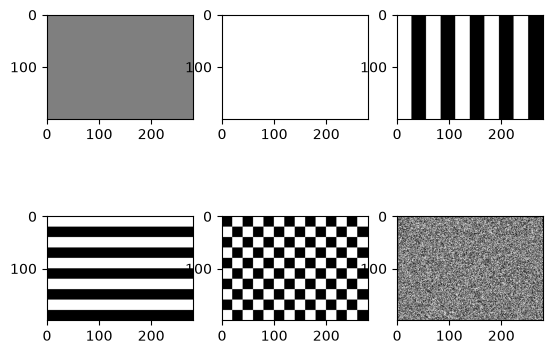

In [7]:
f, onde = plt.subplots(2, 3)
onde[0,0].imshow(imagem1)
onde[0,1].imshow(imagem2)
onde[0,2].imshow(imagem3)
onde[1,0].imshow(imagem4)
onde[1,1].imshow(imagem5)
onde[1,2].imshow(imagem6)

## TAREFA 1B

nao entendi se eh pra fazer com o cv2 ou plt ou o que

<Figure size 640x480 with 0 Axes>

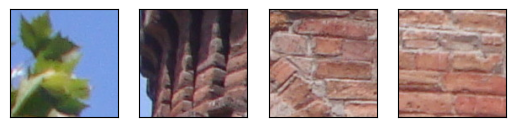

In [8]:
imagemb1 = cv2.imread("img/patch01.jpg", cv2.IMREAD_COLOR)
imagemb1 = cv2.cvtColor(imagemb1, cv2.COLOR_BGR2RGB)

imagemb2 = cv2.imread("img/patch02.jpg", cv2.COLOR_RGB2BGR)
imagemb2 = cv2.cvtColor(imagemb2, cv2.COLOR_BGR2RGB)

imagemb3 = cv2.imread("img/patch03.jpg", cv2.COLOR_RGB2BGR)
imagemb3 = cv2.cvtColor(imagemb3, cv2.COLOR_BGR2RGB)

imagemb4 = cv2.imread("img/patch04.jpg", cv2.COLOR_RGB2BGR)
imagemb4 = cv2.cvtColor(imagemb4, cv2.COLOR_BGR2RGB)

# cv2.imshow("display",imagemb1)

# cv2.waitKey(0)

# cv2.destroyAllWindows()

plt.clf()


a, onde = plt.subplots(1, 4)

for i in range(4):
    onde[i].axes.get_xaxis().set_visible(False)
    onde[i].axes.get_yaxis().set_visible(False)

onde[0].imshow(imagemb1)
onde[1].imshow(imagemb2)
onde[2].imshow(imagemb3)
onde[3].imshow(imagemb4)




## Tarefa 1C
### Usando o Canny sem a webcam

In [ ]:
img = cv2.imread("img/patch01.jpg")
assert img is not None, "couldn't find file"
# transform_gray(img)
# cv2.imwrite("img/gray.jpg", img)
cv2.namedWindow("edges", cv2.WINDOW_AUTOSIZE)

cv2.createTrackbar("kill", "edges", 0, 1, lambda x: None)
cv2.createTrackbar("lower_limit", "edges",0, 254, lambda x: None)
cv2.createTrackbar("upper_limit", "edges", 0, 255, lambda x: None)
while(True):
    lower = cv2.getTrackbarPos("lower_limit", "edges")
    upper = cv2.getTrackbarPos("upper_limit", "edges")
    if(upper < lower):
        cv2.setTrackbarPos("upper_limit","edges", lower+1)
    kill = cv2.getTrackbarPos("kill", "edges")
    edge_detect = cv2.cvtColor(cv2.Canny(img, lower, upper), cv2.COLOR_GRAY2BGR)
    cv2.imshow("edges", np.hstack((edge_detect, img)))
    cv2.waitKey(50)
    if(kill == 1):
        cv2.destroyAllWindows()
        break

### Usando com Webcam

In [25]:
cam_feed = cv2.VideoCapture(0)
assert cam_feed.isOpened() is not False
cv2.namedWindow("edges", cv2.WINDOW_FREERATIO)
cv2.createTrackbar("kill", "edges", 0, 1, lambda x: None)
cv2.createTrackbar("lower_limit", "edges",0, 254, lambda x: None)
cv2.createTrackbar("upper_limit", "edges", 0, 255, lambda x: None) 
cv2.setTrackbarPos("upper_limit", "edges", 100)
val, frame = cam_feed.read()
(h, w, _) = frame.shape
output_array = np.empty((h, 2*w, 3), np.uint8)
while(True):
    val, frame = cam_feed.read()
    lower = cv2.getTrackbarPos("lower_limit", "edges")
    upper = cv2.getTrackbarPos("upper_limit", "edges")
    if(upper < lower):
        cv2.setTrackbarPos("upper_limit","edges", lower+1)
    kill = cv2.getTrackbarPos("kill", "edges")
    edge_detect = cv2.cvtColor(cv2.Canny(frame, lower, upper), cv2.COLOR_GRAY2BGR)
    output_array = np.hstack([edge_detect, frame])
    cv2.imshow("edges", output_array)
    cv2.waitKey(30)
    if(kill == 1):
        cv2.destroyAllWindows()
        cam_feed.release()
        break